# Deliverable #1: Data Exploration

For this deliverable, I used two datasets:

1. The original Kaggle `tweets.csv`
2. The Zenodo disaster tweet files

The main goal is to compare the datasets, check the label distribution, create word clouds, and do n-gram analysis for each outcome.

I also looked more closely at the n-grams because some of the phrases did not immediately look meaningful. I wanted to check whether they were actual tweet patterns or just things created during the text-cleaning process.

In [1]:
from pathlib import Path
from collections import Counter
import zipfile
import json
import re

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", 160)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-uvt_kc72 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load the original Kaggle dataset

In [2]:
kaggle_df = pd.read_csv("tweets.csv")

print(kaggle_df.shape)
kaggle_df.head()

(11370, 5)


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…",1
1,1,ablaze,NaN,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…",1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l… https://t.co/VlTznnPNi8",0


In [3]:
kaggle_clean = kaggle_df[["text", "target"]].copy()
kaggle_clean["source"] = "kaggle"

kaggle_clean.head()

,text,target,source
0,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…",1,kaggle
1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…",1,kaggle
2,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,1,kaggle
3,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,1,kaggle
4,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l… https://t.co/VlTznnPNi8",0,kaggle


## Load the Zenodo dataset

In [4]:
zip_path = Path("ZENODO.zip")
extract_dir = Path("zenodo_files")

if not extract_dir.exists():
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

zenodo_rows = []

for file in extract_dir.rglob("*.ndjson"):
    if "__MACOSX" in str(file):
        continue
        
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                item = json.loads(line)
                zenodo_rows.append({
                    "id": item.get("id"),
                    "text": item.get("text"),
                    "target": item.get("relevance"),
                    "event_file": file.name
                })

zenodo_df = pd.DataFrame(zenodo_rows)

print(zenodo_df.shape)
zenodo_df.head()

(163718, 4)


,id,text,target,event_file
0,406553907700449280,terrible here in glasgow helicopter crashed into roof of pub,1,transportation-glasgow-helicopter-crash-2013.ndjson
1,406555220513394688,helicopter 'crashes into pub in glasgow' <URL> the clutha bar,1,transportation-glasgow-helicopter-crash-2013.ndjson
2,406555392492462080,breaking: a helicopter has crashed in to the roof of a glasgow city centre pub. more to follow.,1,transportation-glasgow-helicopter-crash-2013.ndjson
3,406555799344136193,labour mp jim murphy says a helicopter has crashed into the roof of a pub in glasgow,1,transportation-glasgow-helicopter-crash-2013.ndjson
4,406556302643822592,anybody heard anything about a helicopter crashing into a pub in glasgow  <REPEAT>,1,transportation-glasgow-helicopter-crash-2013.ndjson


In [5]:
zenodo_clean = zenodo_df[["text", "target"]].copy()
zenodo_clean["source"] = "zenodo"

zenodo_clean.head()

,text,target,source
0,terrible here in glasgow helicopter crashed into roof of pub,1,zenodo
1,helicopter 'crashes into pub in glasgow' <URL> the clutha bar,1,zenodo
2,breaking: a helicopter has crashed in to the roof of a glasgow city centre pub. more to follow.,1,zenodo
3,labour mp jim murphy says a helicopter has crashed into the roof of a pub in glasgow,1,zenodo
4,anybody heard anything about a helicopter crashing into a pub in glasgow  <REPEAT>,1,zenodo


The Zenodo files use `relevance` instead of `target`. I converted it into the same `target` format as the Kaggle dataset.

- `0` = non-disaster / not relevant
- `1` = disaster / relevant

## Combine the two datasets

In [6]:
combined_df = pd.concat([kaggle_clean, zenodo_clean], ignore_index=True)

combined_df["text_check"] = combined_df["text"].astype(str).str.lower().str.strip()
before = len(combined_df)

combined_df = combined_df.drop_duplicates(subset="text_check").drop(columns="text_check")
after = len(combined_df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

combined_df.head()

Rows before removing duplicates: 175088
Rows after removing duplicates: 170458
Duplicates removed: 4630


,text,target,source
0,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…",1,kaggle
1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…",1,kaggle
2,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,1,kaggle
3,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,1,kaggle
4,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l… https://t.co/VlTznnPNi8",0,kaggle


In [7]:
combined_df.to_csv("combined_disaster_tweets.csv", index=False)

combined_df.shape

(170458, 3)

## Label distribution

In [8]:
def label_table(data, name):
    counts = data["target"].value_counts().sort_index()
    percentages = data["target"].value_counts(normalize=True).sort_index() * 100
    
    return pd.DataFrame({
        "dataset": name,
        "label": counts.index,
        "count": counts.values,
        "percentage": percentages.round(2).values
    })

label_summary = pd.concat([
    label_table(kaggle_clean, "Kaggle"),
    label_table(zenodo_clean, "Zenodo"),
    label_table(combined_df, "Combined")
], ignore_index=True)

label_summary["label_name"] = label_summary["label"].map({0: "Non-disaster", 1: "Disaster"})
label_summary

,dataset,label,count,percentage,label_name
0,Kaggle,0,9256,81.41,Non-disaster
1,Kaggle,1,2114,18.59,Disaster
2,Zenodo,0,81859,50.00,Non-disaster
3,Zenodo,1,81859,50.00,Disaster
4,Combined,0,88094,51.68,Non-disaster
5,Combined,1,82364,48.32,Disaster


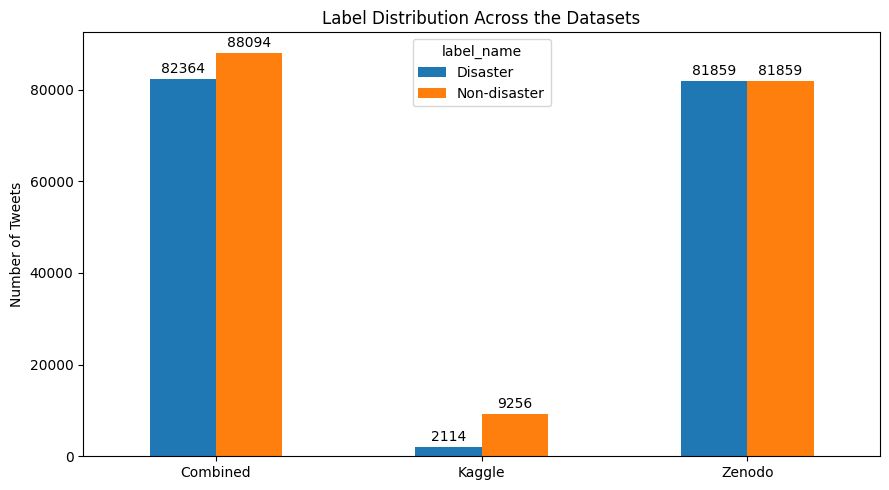

In [9]:
pivot_counts = label_summary.pivot(index="dataset", columns="label_name", values="count")

ax = pivot_counts.plot(kind="bar", figsize=(9, 5))
ax.set_title("Label Distribution Across the Datasets")
ax.set_xlabel("")
ax.set_ylabel("Number of Tweets")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.tight_layout()
plt.show()

The original Kaggle dataset is heavily skewed toward non-disaster tweets. The Zenodo dataset is much more balanced because it has almost the same number of relevant and irrelevant tweets. After combining them, the final dataset is still not perfectly balanced, but it is better than using only the Kaggle dataset.

## Tweet length

In [10]:
combined_df["word_count"] = combined_df["text"].astype(str).apply(lambda x: len(x.split()))
combined_df["char_count"] = combined_df["text"].astype(str).apply(len)

length_summary = combined_df.groupby(["source", "target"])[["word_count", "char_count"]].mean().round(2)
length_summary

word_count  char_count
source target                        
kaggle 0            17.17      106.24
       1            17.45      115.12
zenodo 0            13.69       80.23
       1            16.64      106.65

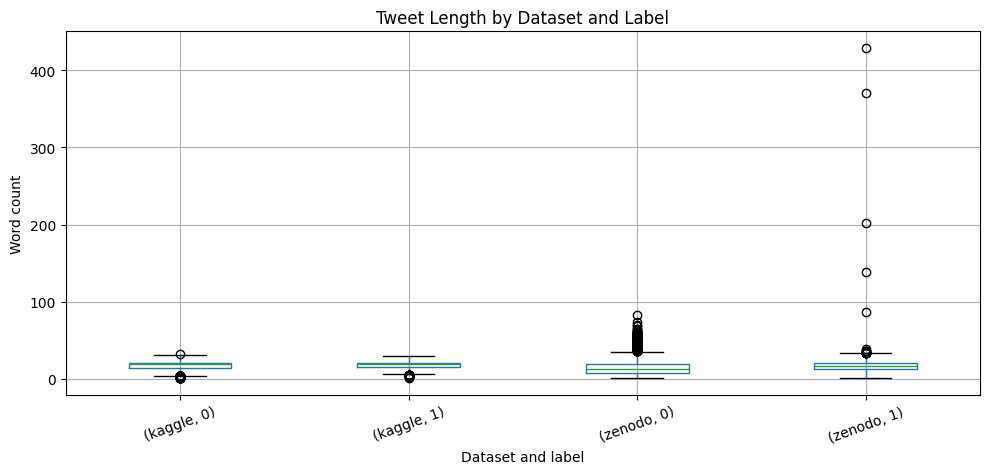

In [11]:
ax = combined_df.boxplot(
    column="word_count",
    by=["source", "target"],
    figsize=(10, 5)
)

plt.title("Tweet Length by Dataset and Label")
plt.suptitle("")
plt.xlabel("Dataset and label")
plt.ylabel("Word count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The tweet lengths are fairly close overall, but this is still worth checking. If one dataset had much longer or much shorter tweets, the model might learn dataset patterns instead of learning disaster language.

## Clean the text

Some phrases in the n-gram results stood out to me, especially things like `number number`, `number earthquake`, `gt gt`, and `repeat smile`. Before treating those as real patterns, I wanted to check where they were coming from.

After looking at the actual tweet text, I realized that some of them came from placeholder tokens and HTML symbols in the Zenodo files, so I handled those before creating the final word clouds and n-grams.

In [12]:
stopwords = set(STOPWORDS)
stopwords.update({
    "https", "http", "co", "amp", "rt", "im", "dont", "via",
    "url", "hashtag", "user", "number", "repeat", "smile",
    "gt", "lt", "nbsp", "quot", "one", "new", "will"
})

def clean_text(text):
    text = str(text).lower()

    # remove placeholders used in the Zenodo files
    text = re.sub(r"<\s*(url|hashtag|user|number|repeat|smile)\s*>", " ", text)

    # remove common html entities
    text = re.sub(r"&amp;|&lt;|&gt;|&quot;|&nbsp;", " ", text)

    # remove normal links and user mentions
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # keep only letters
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

combined_df["clean_text"] = combined_df["text"].fillna("").apply(clean_text)

combined_df[["source", "target", "text", "clean_text"]].head()

,source,target,text,clean_text
0,kaggle,1,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…",communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ablaze
1,kaggle,1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…",telangana section has been imposed in bhainsa from january to after clash erupted between two groups on january po
2,kaggle,1,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,arsonist sets cars ablaze at dealership
3,kaggle,1,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,arsonist sets cars ablaze at dealership
4,kaggle,0,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l… https://t.co/VlTznnPNi8",lord jesus your love brings freedom and pardon fill me with your holy spirit and set my heart ablaze with your l


## Check examples behind suspicious n-grams

In [13]:
def show_original_examples(phrase, label=1, n=5):
    phrase = phrase.lower()
    mask = (
        (combined_df["target"] == label) &
        (combined_df["text"].astype(str).str.lower().str.contains(phrase, regex=False, na=False))
    )
    return combined_df.loc[mask, ["source", "target", "text"]].head(n)

show_original_examples("<number>", label=1, n=5)

,source,target,text
11398,zenodo,1,<USER> helicopter crashes into busy bar in <HASHTAG> glasgow <HASHTAG> clutha http://t.co/yv <NUMBER> 4d <NUMBER> incredible picture
11413,zenodo,1,the police memorial trust confirming it is police scotland helicopter s <NUMBER> involved in the incident in <HASHTAG> glasgow. <HASHTAG> clutha
11416,zenodo,1,thoughts with all at <HASHTAG> clutha <HASHTAG> glasgow <HASHTAG> helicopter <HASHTAG> crash site mt <USER> helicopter crash into pub http://t.co/elurs <NUM...
11432,zenodo,1,our thoughts are with the crew of <USER> s <NUMBER> helicopter that has crashed in glasgow - hoping everyone is alr…
11448,zenodo,1,"glasgow <HASHTAG> helicopter was falling out of sky at great speed, journalist gordonsmart tells bb <NUMBER> ive http://t.co/xttfpufrtc…"


The examples above helped me understand what was happening. The word `number` was not always something a user actually typed. In many cases, it came from `<NUMBER>`, which appears as a placeholder in the Zenodo dataset.

In [14]:
artifact_words = ["number", "gt", "lt", "repeat", "smile"]

for word in artifact_words:
    count = combined_df["clean_text"].str.split().explode().eq(word).sum()
    print(word, count)

number 434


gt 82


lt 342


repeat 69


smile 215


## Word cloud for non-disaster tweets

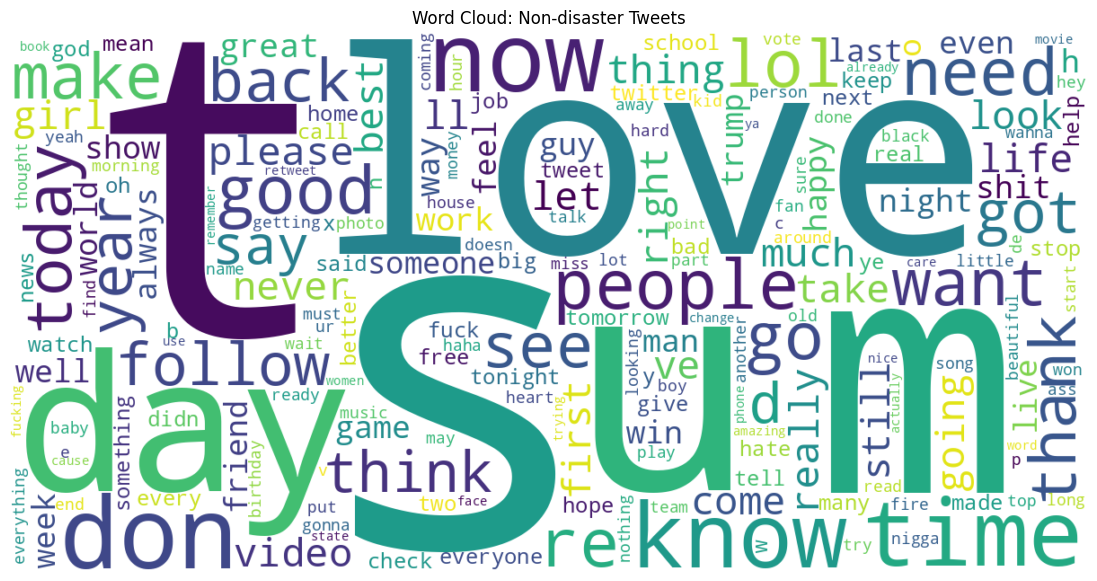

In [15]:
non_disaster_text = " ".join(combined_df.loc[combined_df["target"] == 0, "clean_text"])

wordcloud_0 = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    random_state=42
).generate(non_disaster_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_0, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Non-disaster Tweets")
plt.show()

## Word cloud for disaster tweets

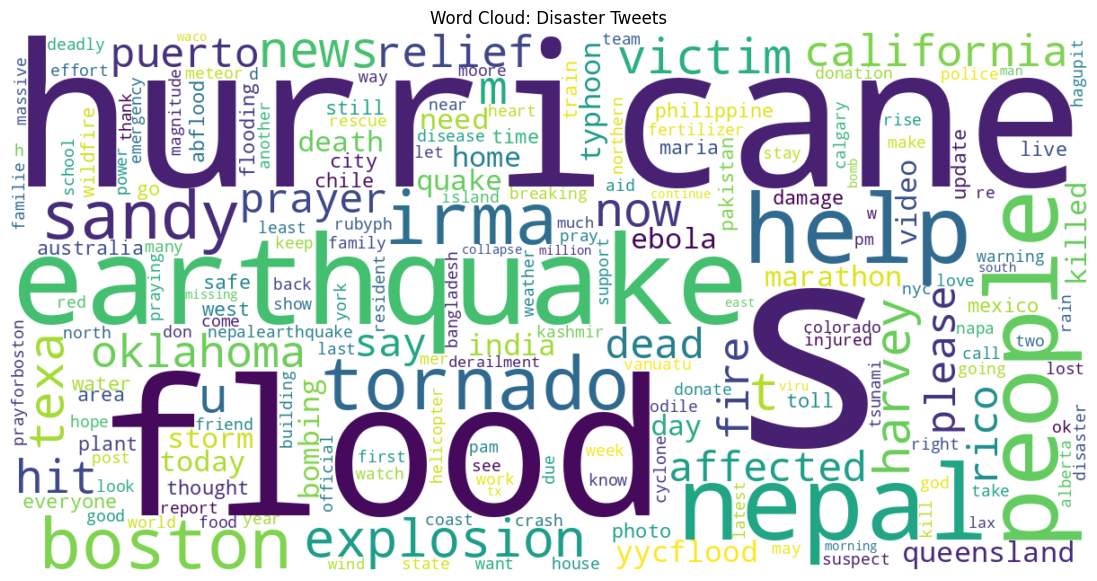

In [16]:
disaster_text = " ".join(combined_df.loc[combined_df["target"] == 1, "clean_text"])

wordcloud_1 = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    random_state=42
).generate(disaster_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_1, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Disaster Tweets")
plt.show()

The disaster word cloud is more connected to actual events like fires, floods, earthquakes, shootings, crashes, and other emergencies. The non-disaster word cloud has more general and conversational language. There is still some overlap though, because people can use disaster-related words casually.

## N-gram analysis

In [17]:
def get_top_ngrams(text_series, ngram_range=(2, 2), top_n=15):
    vectorizer = CountVectorizer(
        stop_words=list(stopwords),
        ngram_range=ngram_range,
        min_df=2
    )
    
    matrix = vectorizer.fit_transform(text_series)
    counts = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    
    result = pd.DataFrame({
        "ngram": terms,
        "count": counts
    }).sort_values("count", ascending=False).head(top_n)
    
    return result.reset_index(drop=True)

### Top bigrams after fixing the cleaning

In [18]:
non_disaster_bigrams = get_top_ngrams(
    combined_df.loc[combined_df["target"] == 0, "clean_text"],
    ngram_range=(2, 2)
)

disaster_bigrams = get_top_ngrams(
    combined_df.loc[combined_df["target"] == 1, "clean_text"],
    ngram_range=(2, 2)
)

print("Non-disaster bigrams")
display(non_disaster_bigrams)

print("Disaster bigrams")
display(disaster_bigrams)

/opt/pyvenv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


Non-disaster bigrams


,ngram,count
0,right now,357
1,happy birthday,306
2,don know,231
3,last night,231
4,please follow,199
5,liked video,172
6,love much,161
7,good morning,141
8,don want,131
9,first time,128


Disaster bigrams


,ngram,count
0,hurricane sandy,2342
1,puerto rico,2169
2,boston marathon,1415
3,hurricane irma,1372
4,death toll,1217
5,hurricane maria,1095
6,fertilizer plant,1085
7,plant explosion,971
8,hurricane harvey,769
9,queensland flood,669


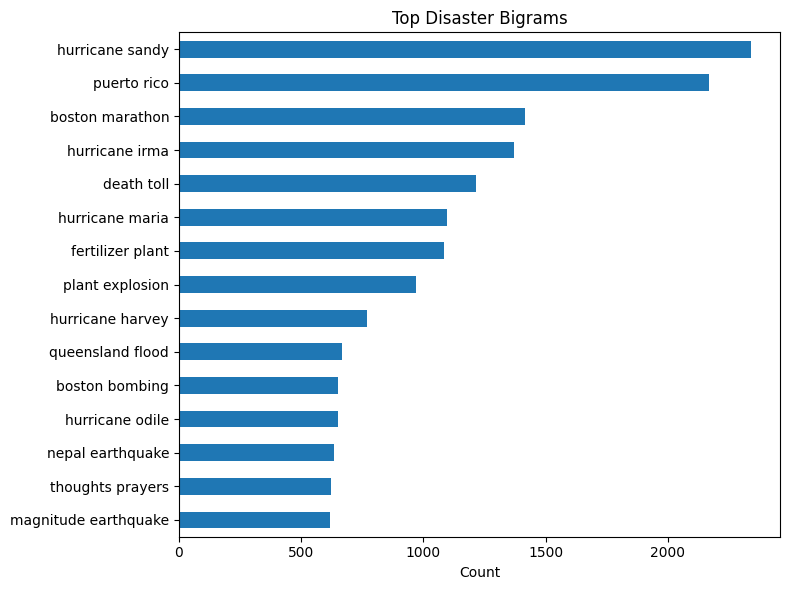

In [19]:
ax = disaster_bigrams.sort_values("count").plot(
    x="ngram",
    y="count",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

ax.set_title("Top Disaster Bigrams")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

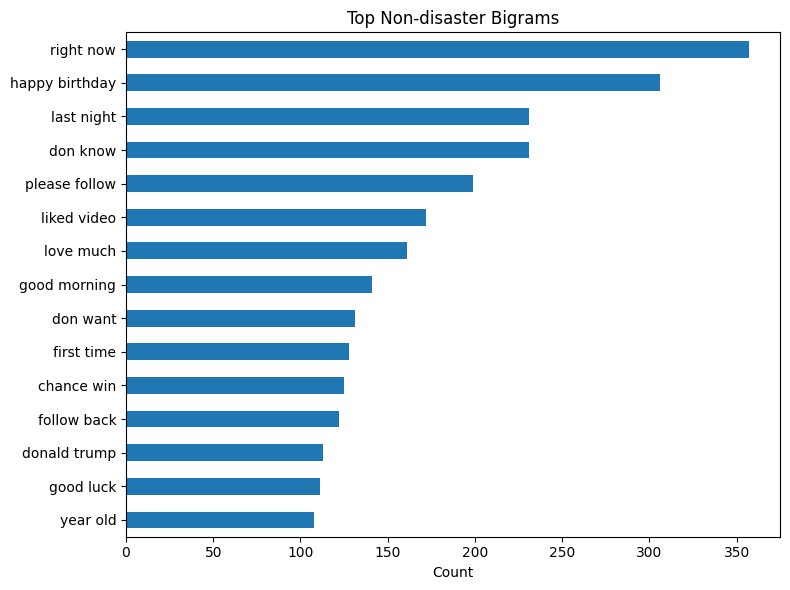

In [20]:
ax = non_disaster_bigrams.sort_values("count").plot(
    x="ngram",
    y="count",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

ax.set_title("Top Non-disaster Bigrams")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Example tweets for meaningful n-grams

In [21]:
def show_clean_examples(phrase, label=1, n=5):
    phrase = phrase.lower()
    mask = (
        (combined_df["target"] == label) &
        (combined_df["clean_text"].str.contains(phrase, regex=False, na=False))
    )
    return combined_df.loc[mask, ["source", "target", "text", "clean_text"]].head(n)

top_disaster_phrase = disaster_bigrams.loc[0, "ngram"]
print("Top disaster bigram:", top_disaster_phrase)

show_clean_examples(top_disaster_phrase, label=1, n=5)

Top disaster bigram: hurricane sandy


,source,target,text,clean_text
25053,zenodo,1,earthquake in guatemala. hurricane sandy in new york! yeah i feel like cali is next!,earthquake in guatemala hurricane sandy in new york yeah i feel like cali is next
54849,zenodo,1,we spend billions of dollars helping nations all over the world but with hurricane sandy and oklahoma tornado not one …,we spend billions of dollars helping nations all over the world but with hurricane sandy and oklahoma tornado not one
55276,zenodo,1,oklahoma's gop senators had opposed aid for hurricane sandy victims. that would be funny if monday's tornado wasn't so tragic  <REPEAT>,oklahoma s gop senators had opposed aid for hurricane sandy victims that would be funny if monday s tornado wasn t so tragic
56022,zenodo,1,do you guys remember when the oklahoma senators voted against hurricane sandy relief  <REPEAT>,do you guys remember when the oklahoma senators voted against hurricane sandy relief
56968,zenodo,1,that one time oklahoma senators were like fuck hurricane sandy victims  <REPEAT> <URL>,that one time oklahoma senators were like fuck hurricane sandy victims


In [22]:
top_non_disaster_phrase = non_disaster_bigrams.loc[0, "ngram"]
print("Top non-disaster bigram:", top_non_disaster_phrase)

show_clean_examples(top_non_disaster_phrase, label=0, n=5)

Top non-disaster bigram: right now


,source,target,text,clean_text
210,kaggle,0,#IranProtests #Tehran Right now Valiasr intersection is where the Special Forces are heading to the Paradise Ambulance. @…,iranprotests tehran right now valiasr intersection is where the special forces are heading to the paradise ambulance
644,kaggle,0,feeling attacked right now https://t.co/x59FZGR1Jb,feeling attacked right now
729,kaggle,0,K-One Its offline protest is ongoing right now. LED trucks are currently in Yuehua. One Its! This fight is not an over…,k one its offline protest is ongoing right now led trucks are currently in yuehua one its this fight is not an over
1191,kaggle,0,My blood is boiling right now 😤🤯but I wouldn’t expect anything less from the racist mofo!!! Arabs/S… https://t.co/nlpLDICtcI,my blood is boiling right now but i wouldn t expect anything less from the racist mofo arabs s
1488,kaggle,0,You know what sounds bomb right now? A chicken sandwich from Whataburger 😭,you know what sounds bomb right now a chicken sandwich from whataburger


Looking at the actual examples helps make sure the n-grams are meaningful. It also makes it easier to tell whether a phrase is coming from real tweet language or from how the dataset represented certain tokens.

### Top trigrams

In [23]:
non_disaster_trigrams = get_top_ngrams(
    combined_df.loc[combined_df["target"] == 0, "clean_text"],
    ngram_range=(3, 3)
)

disaster_trigrams = get_top_ngrams(
    combined_df.loc[combined_df["target"] == 1, "clean_text"],
    ngram_range=(3, 3)
)

print("Non-disaster trigrams")
display(non_disaster_trigrams)

print("Disaster trigrams")
display(disaster_trigrams)

/opt/pyvenv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


Non-disaster trigrams


,ngram,count
0,android androidgames gameinsight,67
1,added video playlist,67
2,ve collected gold,53
3,collected gold coins,53
4,iheartawards bestfanarmy btsarmy,47
5,follow chance win,37
6,ipad ipadgames gameinsight,35
7,party gove heart,34
8,triumphant party gove,34
9,gold coins android,34


Disaster trigrams


,ngram,count
0,fertilizer plant explosion,678
1,texas fertilizer plant,410
2,boston marathon bombing,361
3,death toll rises,210
4,queensland flood crisis,200
5,explosion west texas,187
6,bangladesh building collapse,179
7,boston marathon bombings,172
8,thoughts prayers go,171
9,explosion near waco,167


The bigrams and trigrams are more useful than individual words because they give more context. For example, a single word like `fire` could be used casually, but a phrase around it can make the meaning clearer.

## Train and test split

In [24]:
X = combined_df["clean_text"]
y = combined_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

split_check = pd.DataFrame({
    "train_percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "test_percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})

split_check.index = split_check.index.map({0: "Non-disaster", 1: "Disaster"})
split_check

Training set: (136366,)
Test set: (34092,)


,train_percentage,test_percentage
target,,
Non-disaster,51.68,51.68
Disaster,48.32,48.32


I used a stratified train/test split so that the label distribution stays similar in both sets. This matters because the combined dataset is better than the original one, but it is still not perfectly balanced.

## Model direction

Based on this dataset, logistic regression is the most appropriate starting model. The outcome is binary, so multiple linear regression does not fit the task. Decision trees and random forests could be tested later, but logistic regression is a strong baseline for text classification after converting the tweets into numerical features with TF-IDF.

For evaluation, I would start with F1-score because it balances precision and recall. I would still report precision and recall separately because false positives and false negatives both matter here.

## Final notes

One thing I took away from this part of the exploration is that text cleaning really affects what the n-grams show. Some phrases that looked important at first were actually coming from placeholders in the Zenodo files, so checking real tweet examples was helpful.

Overall, the combined dataset gives us more disaster examples than the original Kaggle dataset alone. The Zenodo dataset also adds tweets from specific real-world events, which should make the disaster class stronger for the next stage of the project.

# Model Training and Evaluation

For the model, I started with logistic regression. This makes sense because the outcome is binary:

- `0` = non-disaster
- `1` = disaster

Since the input is text, I used TF-IDF to convert the tweets into numerical features before training the model. I also used unigrams and bigrams because the EDA showed that phrases can give more context than single words.


In [1]:
import re

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 160)

## Prepare the data for modeling

In [2]:
combined_df = pd.read_csv("combined_disaster_tweets.csv")

stopwords = set(STOPWORDS)
stopwords.update({
    "https", "http", "co", "amp", "rt", "im", "dont", "via",
    "url", "hashtag", "user", "number", "repeat", "smile",
    "gt", "lt", "nbsp", "quot", "one", "new", "will"
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<\s*(url|hashtag|user|number|repeat|smile)\s*>", " ", text)
    text = re.sub(r"&amp;|&lt;|&gt;|&quot;|&nbsp;", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

combined_df["clean_text"] = combined_df["text"].fillna("").apply(clean_text)

print(combined_df.shape)
combined_df[["source", "target", "text", "clean_text"]].head()

(170458, 4)


,source,target,text,clean_text
0,kaggle,1,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…",communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ablaze
1,kaggle,1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…",telangana section has been imposed in bhainsa from january to after clash erupted between two groups on january po
2,kaggle,1,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI,arsonist sets cars ablaze at dealership
3,kaggle,1,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9,arsonist sets cars ablaze at dealership
4,kaggle,0,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l… https://t.co/VlTznnPNi8",lord jesus your love brings freedom and pardon fill me with your holy spirit and set my heart ablaze with your l


## Train/test split

In [3]:
X = combined_df["clean_text"]
y = combined_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

split_check = pd.DataFrame({
    "train_percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "test_percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})

split_check.index = split_check.index.map({0: "Non-disaster", 1: "Disaster"})
split_check

Training set: (136366,)
Test set: (34092,)


,train_percentage,test_percentage
target,,
Non-disaster,51.68,51.68
Disaster,48.32,48.32


I used a stratified split so that the train and test sets keep a similar balance of disaster and non-disaster tweets. This matters because even though the combined dataset is much better than the original dataset alone, I still do not want the split to distort the labels.

## Logistic Regression model

In [4]:
log_reg_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        max_features=50000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

y_pred = log_reg_model.predict(X_test)

## Model evaluation

In [5]:
results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

results["score"] = results["score"].round(4)
results

,metric,score
0,accuracy,0.9622
1,precision,0.9774
2,recall,0.9435
3,f1,0.9602


In [6]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-disaster", "Disaster"]
))

              precision    recall  f1-score   support

Non-disaster       0.95      0.98      0.96     17619
    Disaster       0.98      0.94      0.96     16473

    accuracy                           0.96     34092
   macro avg       0.96      0.96      0.96     34092
weighted avg       0.96      0.96      0.96     34092



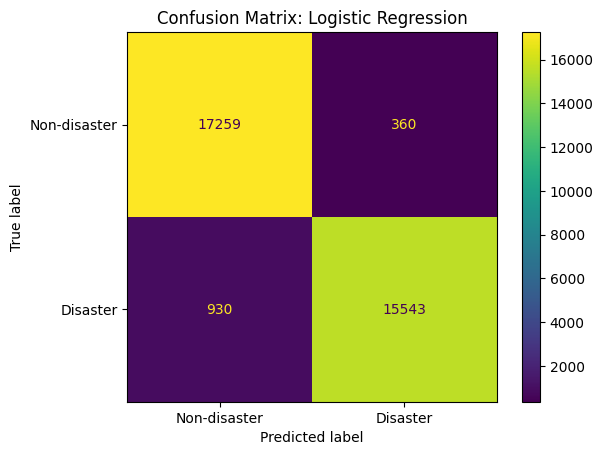

In [7]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-disaster", "Disaster"]
)

disp.plot()
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

For this problem, I would not judge the model by accuracy alone. I am more interested in precision, recall, and F1-score.

F1-score is a good main metric because it balances precision and recall. Precision matters because too many false alarms could make the output less useful. Recall also matters because missing real disaster tweets would be a problem.

## Look at prediction examples

In [8]:
test_results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

test_results["result_type"] = "correct"
test_results.loc[(test_results["actual"] == 0) & (test_results["predicted"] == 1), "result_type"] = "false_positive"
test_results.loc[(test_results["actual"] == 1) & (test_results["predicted"] == 0), "result_type"] = "false_negative"

test_results["result_type"].value_counts()

result_type
correct           32802
false_negative      930
false_positive      360
Name: count, dtype: int64

### False positives

In [9]:
test_results[test_results["result_type"] == "false_positive"][["text", "actual", "predicted"]].head(10)

,text,actual,predicted
6508,campaign staffer helping keep track of thank you notes she ll help with yours too once you donate,0,1
142196,some schools in puerto rico are due to open monday with no lights no water and no food,0,1
160601,hope that all passengers who missing at flight from kl to beijing this morning is stay safe prayform,0,1
85987,macbook pro silver calgary calgary ab,0,1
117513,x games athlete caleb moore has died after injuries sustained in snowmobile freestyle event thoughts prayers go,0,1
94324,shri chaired a high level meeting with railway board officials to ensure safety in train operations http,0,1
137665,flood warning in chelsea yes i am out tonight,0,1
10724,never underestimate the power of validating other people s feelings validation creates a safe zone for the threatened ins,0,1
5950,fires have also affected the alpine habitat of the endangered southern corroboree frog and the forest and sub alpin,0,1
10143,tornado,0,1


False positives are tweets the model predicted as disaster even though the actual label was non-disaster. I wanted to look at these because some tweets use disaster-related words casually or without actually reporting an emergency.

### False negatives

In [10]:
test_results[test_results["result_type"] == "false_negative"][["text", "actual", "predicted"]].head(10)

,text,actual,predicted
98445,thanks,1,0
26512,of female inmates who escaped from prison during chileearthquake are back behind bars officials say most retur,1,0
27019,the amazing spider man crawls into the mtv movie awards via,1,0
44417,in watertown tho this is fuckin crazy bostonweareone,1,0
17516,hatesup to indian airforce we are proud of our defence forces whether it is ground military airforce or navy,1,0
148608,the aftermath of the moral and social bankruptcy orchestrated in the bbnaija show,1,0
63887,this looks like the best facebook page for west their preferred donation now is money and blood w,1,0
150923,flashlights were all sold out scored the last box of emergency shabbat candles from local deli it s eerily dark and quiet in manhattan,1,0
82166,ristine not according to fema,1,0
76717,i know that papa god will always be there to protect us we need to trust him let s have a bigger faith on him prayforvisayas,1,0


False negatives are tweets the model missed even though they were actually disaster tweets. These are important to check because if this were being used in a real response setting, missed disaster tweets could matter a lot.

## Most important words and phrases

In [11]:
tfidf = log_reg_model.named_steps["tfidf"]
classifier = log_reg_model.named_steps["classifier"]

feature_names = tfidf.get_feature_names_out()
coefficients = classifier.coef_[0]

top_disaster_features = pd.DataFrame({
    "word_or_phrase": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False).head(20)

top_non_disaster_features = pd.DataFrame({
    "word_or_phrase": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=True).head(20)

print("Features pushing the model toward disaster")
display(top_disaster_features)

print("Features pushing the model toward non-disaster")
display(top_non_disaster_features)

Features pushing the model toward disaster


,word_or_phrase,coefficient
17397,hurricane,22.790546
45620,tornado,19.152228
27916,nepal,19.123917
19142,irma,18.677921
15020,harvey,17.704542
9819,earthquake,17.478051
12153,flood,16.444980
49905,yycflood,15.711187
38790,sandy,15.529225
3473,boston,15.069731


Features pushing the model toward non-disaster


,word_or_phrase,coefficient
17219,https,-3.056938
47870,vote,-2.805939
48966,win,-2.618022
19863,jobs,-2.460853
23433,lol,-2.290673
46223,trump,-2.180857
27158,music,-2.100321
47804,voicesavekennedy,-2.087800
41675,song,-2.087482
15158,hate,-2.028740


This helps me understand what the model is using. Positive coefficients push the model toward the disaster class, while negative coefficients push it toward the non-disaster class.

## Model takeaway

The logistic regression model is a strong baseline for this project. It is simple enough to explain, but still works well with TF-IDF text features.

The model has now been trained and evaluated using a train/test split. For the next stage, I would compare it with at least one other model and keep F1-score as the main metric while still looking closely at precision and recall.